In [1]:
import random
import time
import community as community_louvain
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from collections import Counter, defaultdict
import numpy as np

In [2]:
def label_propagation(G, max_iter=100, seed=None):
    if seed is not None:
        random.seed(seed)
    labels = {node: node for node in G.nodes()}
    for iteration in range(max_iter):
        nodes = list(G.nodes())
        random.shuffle(nodes)
        changed = False
        for node in nodes:
            neighbors = list(G.neighbors(node))
            if not neighbors:
                continue
            neighbor_labels = [labels[n] for n in neighbors]
            label_counts = Counter(neighbor_labels)
            max_count = max(label_counts.values())
            most_common = [label for label, count in label_counts.items() if count == max_count]
            new_label = random.choice(most_common)
            if labels[node] != new_label:
                labels[node] = new_label
                changed = True
        if not changed:
            return labels, iteration + 1
    return labels, max_iter

In [3]:
def calculate_modularity_from_labels(G, labels):
    communities = defaultdict(set)
    for node, comm_id in labels.items():
        communities[comm_id].add(node)
    communities_list = list(communities.values())
    m = G.number_of_edges()
    if m == 0:
        return 0.0
    Q = 0.0
    for u in G.nodes():
        for v in G.nodes():
            A_uv = 1 if G.has_edge(u, v) else 0
            k_u = G.degree(u)
            k_v = G.degree(v)
            if labels[u] == labels[v]:
                Q += A_uv - (k_u * k_v) / (2 * m)
    Q = Q / (2 * m)
    return Q

In [4]:
def algorithm_comparison(G, num_runs=5):
    results = []
    print("Deploying Algorithm 1: Louvain...")
    for run in range(num_runs):
        start_time = time.time()
        partition = community_louvain.best_partition(G, random_state=run)
        elapsed = time.time() - start_time
        modularity = community_louvain.modularity(partition, G)
        num_communities = len(set(partition.values()))
        community_sizes = Counter(partition.values())
        largest = max(community_sizes.values())
        smallest = min(community_sizes.values())
        results.append({'algorithm': 'Louvain', 'run': run, 'time': elapsed, 'num_communities': num_communities, 'modularity': modularity, 'largest_community': largest, 'smallest_community': smallest})
    print("Deploying Algorithm 2: Label Propagation...")
    for run in range(num_runs):
        start_time = time.time()
        labels, iterations = label_propagation(G, max_iter=100, seed=run)
        elapsed = time.time() - start_time
        modularity = calculate_modularity_from_labels(G, labels)
        num_communities = len(set(labels.values()))
        community_sizes = Counter(labels.values())
        largest = max(community_sizes.values())
        smallest = min(community_sizes.values())
        results.append({'algorithm': 'Label Propagation', 'run': run, 'time': elapsed, 'num_communities': num_communities, 'modularity': modularity, 'largest_community': largest, 'smallest_community': smallest})
    print("Deploying Algorithm 3: Greedy Modularity...")
    for run in range(num_runs):
        start_time = time.time()
        communities = nx.algorithms.community.greedy_modularity_communities(G)
        elapsed = time.time() - start_time
        partition = {}
        for idx, comm in enumerate(communities):
            for node in comm:
                partition[node] = idx
        modularity = calculate_modularity_from_labels(G, partition)
        num_communities = len(communities)
        community_sizes = [len(c) for c in communities]
        largest = max(community_sizes)
        smallest = min(community_sizes)
        results.append({'algorithm': 'Greedy Modularity', 'run': run, 'time': elapsed, 'num_communities': num_communities, 'modularity': modularity, 'largest_community': largest, 'smallest_community': smallest})
    df = pd.DataFrame(results)
    summary = df.groupby('algorithm').agg({'time': ['mean', 'std'], 'num_communities': 'mean', 'modularity': ['mean', 'std'], 'largest_community': 'mean', 'smallest_community': 'mean'}).round(4)
    summary.columns = ['avg_time', 'std_time', 'avg_num_communities', 'avg_modularity', 'std_modularity', 'largest_community_size', 'smallest_community_size']
    summary = summary.reset_index()
    return summary

In [5]:
def deep_analysis(G, best_partition):
    analysis = {}
    community_to_nodes = defaultdict(list)
    for node, comm in best_partition.items():
        community_to_nodes[comm].append(node)
    bridges = []
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        neighbor_communities = set(best_partition[n] for n in neighbors)
        if len(neighbor_communities) >= 3:
            bridges.append({'node': node, 'degree': G.degree(node), 'communities_connected': len(neighbor_communities)})
    analysis['bridges'] = sorted(bridges, key=lambda x: x['communities_connected'], reverse=True)
    central_per_community = {}
    for comm_id, nodes in community_to_nodes.items():
        subgraph = G.subgraph(nodes)
        if len(nodes) > 0:
            centrality = nx.betweenness_centrality(subgraph)
            most_central = max(centrality, key=centrality.get)
            central_per_community[comm_id] = {'node': most_central, 'centrality': centrality[most_central]}
    analysis['central_per_community'] = central_per_community
    largest_comm_id = max(community_to_nodes, key=lambda k: len(community_to_nodes[k]))
    analysis['largest_community'] = {'id': largest_comm_id, 'size': len(community_to_nodes[largest_comm_id]), 'members': community_to_nodes[largest_comm_id]}
    intra_edges = 0
    inter_edges = 0
    for u, v in G.edges():
        if best_partition[u] == best_partition[v]:
            intra_edges += 1
        else:
            inter_edges += 1
    total_edges = intra_edges + inter_edges
    ratio = intra_edges / inter_edges if inter_edges > 0 else float('inf')
    analysis['edge_distribution'] = {'intra': intra_edges, 'inter': inter_edges, 'ratio': ratio}
    return analysis

In [6]:
def visualize_communities(G, partition, analysis):
    fig = plt.figure(figsize=(20, 12))
    ax1 = plt.subplot(2, 3, 1)
    pos = nx.spring_layout(G, seed=42)
    num_communities = len(set(partition.values()))
    colors = plt.cm.tab20(range(num_communities))
    node_colors = [colors[partition[node]] for node in G.nodes()]
    nx.draw_networkx(G, pos, node_color=node_colors, node_size=300, with_labels=True, font_size=6, ax=ax1)
    ax1.set_title('Network with Communities')
    ax1.axis('off')
    ax2 = plt.subplot(2, 3, 2)
    community_sizes = Counter(partition.values())
    sizes = list(community_sizes.values())
    ax2.hist(sizes, bins=20, edgecolor='black')
    ax2.set_xlabel('Community Size')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Community Size Distribution')
    ax3 = plt.subplot(2, 3, 3)
    num_comm = len(set(partition.values()))
    connection_matrix = np.zeros((num_comm, num_comm))
    for u, v in G.edges():
        comm_u = partition[u]
        comm_v = partition[v]
        connection_matrix[comm_u][comm_v] += 1
        connection_matrix[comm_v][comm_u] += 1
    sns.heatmap(connection_matrix, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax3)
    ax3.set_title('Inter-Community Connections')
    ax4 = plt.subplot(2, 3, 4)
    if analysis['bridges']:
        bridge_nodes = [b['node'] for b in analysis['bridges'][:10]]
        bridge_colors = ['red' if node in bridge_nodes else 'lightgray' for node in G.nodes()]
        nx.draw_networkx(G, pos, node_color=bridge_colors, node_size=300, with_labels=True, font_size=6, ax=ax4)
    ax4.set_title('Bridge Nodes Highlighted')
    ax4.axis('off')
    ax5 = plt.subplot(2, 3, 5)
    degrees = [G.degree(node) for node in G.nodes()]
    ax5.hist(degrees, bins=20, edgecolor='black')
    ax5.set_xlabel('Degree')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Degree Distribution')
    ax6 = plt.subplot(2, 3, 6)
    stats_text = f"Communities: {num_communities}\n"
    stats_text += f"Bridges: {len(analysis['bridges'])}\n"
    stats_text += f"Largest Community: {analysis['largest_community']['size']} nodes\n"
    stats_text += f"Intra-edges: {analysis['edge_distribution']['intra']}\n"
    stats_text += f"Inter-edges: {analysis['edge_distribution']['inter']}\n"
    stats_text += f"Ratio: {analysis['edge_distribution']['ratio']:.2f}"
    ax6.text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center')
    ax6.axis('off')
    ax6.set_title('Network Statistics')
    plt.tight_layout()
    plt.savefig('figures/q5_les_miserables_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

OPERATION: RAPID DETECTION
Target Network: Les Miserables
Nodes: 77
Edges: 254
Density: 0.0868
Deploying Algorithm 1: Louvain...
Deploying Algorithm 2: Label Propagation...
Deploying Algorithm 3: Greedy Modularity...

ALGORITHM COMPARISON RESULTS
        algorithm  avg_time  std_time  avg_num_communities  avg_modularity  std_modularity  largest_community_size  smallest_community_size
Greedy Modularity    0.0049    0.0004                  5.0          0.5006          0.0000                    26.0                      6.0
Label Propagation    0.0019    0.0012                  5.0          0.5219          0.0154                    31.2                      6.4
          Louvain    0.0028    0.0008                  6.0          0.5658          0.0005                    24.0                      6.0

BEST ALGORITHM: Louvain
Modularity: 0.5658 (±0.0005)
Time: 0.0028s (±0.0008s)
Communities: 6.0


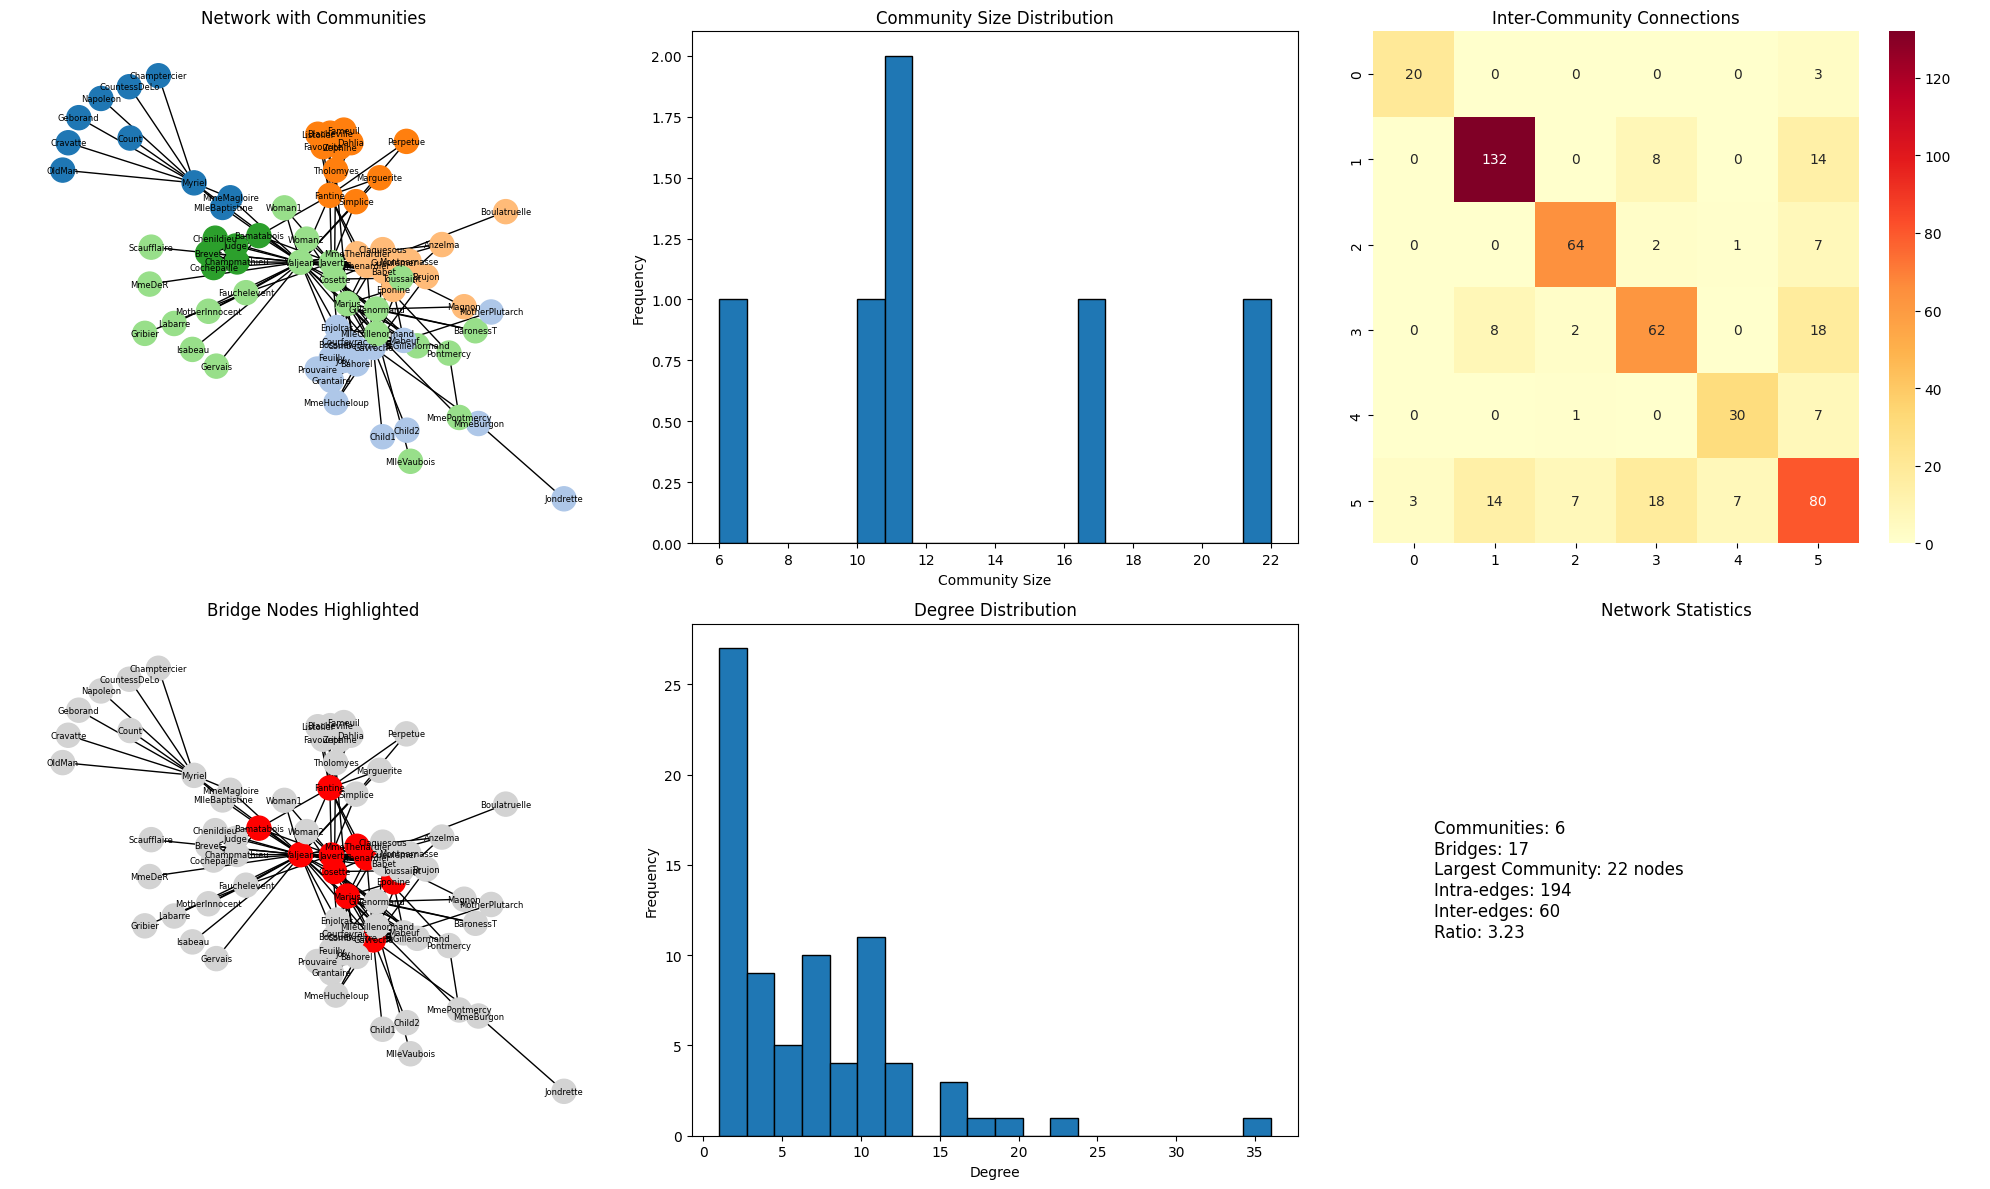

In [7]:
G = nx.les_miserables_graph()
print("=" * 80)
print("OPERATION: RAPID DETECTION")
print("=" * 80)
print(f"Target Network: Les Miserables")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")
comparison_df = algorithm_comparison(G, num_runs=5)
print("\n" + "=" * 80)
print("ALGORITHM COMPARISON RESULTS")
print("=" * 80)
print(comparison_df.to_string(index=False))
comparison_df.to_csv('results/q5_algorithm_comparison.csv', index=False)
best_idx = comparison_df['avg_modularity'].idxmax()
best_algo = comparison_df.iloc[best_idx]
print("\n" + "=" * 80)
print(f"BEST ALGORITHM: {best_algo['algorithm']}")
print("=" * 80)
print(f"Modularity: {best_algo['avg_modularity']:.4f} (±{best_algo['std_modularity']:.4f})")
print(f"Time: {best_algo['avg_time']:.4f}s (±{best_algo['std_time']:.4f}s)")
print(f"Communities: {best_algo['avg_num_communities']:.1f}")
best_partition = community_louvain.best_partition(G)
analysis = deep_analysis(G, best_partition)
visualize_communities(G, best_partition, analysis)